In [2]:
%pip install pandas numpy matplotlib seaborn openpyxl

  Using cached pandas-3.0.5-cp314-cp314-win_amd64.whl.metadata (19 kB)
  Using cached numpy-2.5.3-cp314-cp314-win_amd64.whl.metadata (6.6 kB)
  Using cached matplotlib-3.11.2-cp314-cp314-win_amd64.whl.metadata (80 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached tzdata-2026.4-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached contourpy-1.4.0-cp314-cp314-win_amd64.whl.metadata (3.8 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.65.0-cp314-cp314-win_amd64.whl.metadata (127 kB)
  Using cached kiwisolver-1.5.1-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.3.0-cp314-cp314-win_amd64.whl.metadata (9.3 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
Using cached pandas-3.0.5-cp314-cp314-win_amd64.whl (10.0 MB)
Using cached numpy-2.


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load customer churn dataset
df = pd.read_csv("../data/customer_churn_data.csv")

# Display first 5 rows
df.head()

,Customer_ID,Age,Gender,Region,Plan,Contract_Type,Payment_Method,Tenure_Months,Monthly_Charge,Support_Calls,Satisfaction_Score,Usage_Hours,Lifetime_Value,Churn,Churn_Reason
0,CUST_0001,56,Male,North,Premium,Monthly,UPI,8,77.43,1,8.9,54,619.44,No,Not Churned
1,CUST_0002,46,Female,West,Basic,Monthly,UPI,33,29.12,2,8.9,61,960.96,Yes,Competitor Offer
2,CUST_0003,32,Male,Central,Standard,One Year,Credit Card,2,54.77,3,5.7,58,109.54,Yes,High Price
3,CUST_0004,60,Male,North,Premium,One Year,Debit Card,30,71.83,2,7.3,70,2154.90,No,Not Churned
4,CUST_0005,25,Male,Central,Standard,Monthly,Bank Transfer,47,45.87,3,8.3,12,2155.89,Yes,Competitor Offer


In [4]:
print("Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (1500, 15)

Missing Values:
Customer_ID           0
Age                   0
Gender                0
Region                0
Plan                  0
Contract_Type         0
Payment_Method        0
Tenure_Months         0
Monthly_Charge        0
Support_Calls         0
Satisfaction_Score    0
Usage_Hours           0
Lifetime_Value        0
Churn                 0
Churn_Reason          0
dtype: int64

Duplicate Rows: 0

Data Types:
Customer_ID               str
Age                     int64
Gender                    str
Region                    str
Plan                      str
Contract_Type             str
Payment_Method            str
Tenure_Months           int64
Monthly_Charge        float64
Support_Calls           int64
Satisfaction_Score    float64
Usage_Hours             int64
Lifetime_Value        float64
Churn                     str
Churn_Reason              str
dtype: object


In [5]:
print("Churn Distribution:")
print(df["Churn"].value_counts())

print("\nChurn Percentage:")
print(
    df["Churn"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Churn Distribution:
Churn
No     963
Yes    537
Name: count, dtype: int64

Churn Percentage:
Churn
No     64.2
Yes    35.8
Name: proportion, dtype: float64


In [6]:
df.describe()


,Age,Tenure_Months,Monthly_Charge,Support_Calls,Satisfaction_Score,Usage_Hours,Lifetime_Value
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.00000
mean,41.285333,29.799333,53.951327,2.027333,6.932333,52.040000,1616.27792
std,13.480495,17.299323,24.909519,1.449593,1.491242,27.931055,1274.17238
min,18.000000,1.000000,20.030000,0.000000,2.200000,5.000000,23.49000
25%,29.000000,15.000000,34.505000,1.000000,5.900000,28.000000,617.71500
50%,42.000000,29.000000,49.600000,2.000000,6.900000,53.000000,1299.30000
75%,53.000000,45.000000,65.917500,3.000000,8.000000,76.000000,2267.56000
max,64.000000,60.000000,119.990000,8.000000,10.000000,100.000000,6766.28000


In [7]:
# Remove duplicates
df = df.drop_duplicates()

# Remove missing values
df = df.dropna()

# Convert numerical columns
numeric_columns = [
    "Age",
    "Tenure_Months",
    "Monthly_Charge",
    "Support_Calls",
    "Satisfaction_Score",
    "Usage_Hours",
    "Lifetime_Value"
]

for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

df = df.dropna().reset_index(drop=True)

print("Cleaned Dataset Shape:", df.shape)
print("Missing Values:", df.isnull().sum().sum())
print("Duplicate Rows:", df.duplicated().sum())

Cleaned Dataset Shape: (1500, 15)
Missing Values: 0
Duplicate Rows: 0


In [8]:
total_customers = df["Customer_ID"].nunique()

churned_customers = df[df["Churn"] == "Yes"]["Customer_ID"].nunique()
retained_customers = df[df["Churn"] == "No"]["Customer_ID"].nunique()

churn_rate = (churned_customers / total_customers) * 100
retention_rate = (retained_customers / total_customers) * 100

average_tenure = df["Tenure_Months"].mean()
average_lifetime_value = df["Lifetime_Value"].mean()
average_monthly_charge = df["Monthly_Charge"].mean()
average_satisfaction = df["Satisfaction_Score"].mean()

print("Total Customers:", total_customers)
print("Churned Customers:", churned_customers)
print("Retained Customers:", retained_customers)
print("Churn Rate: {:.2f}%".format(churn_rate))
print("Retention Rate: {:.2f}%".format(retention_rate))
print("Average Tenure: {:.2f} months".format(average_tenure))
print("Average Lifetime Value: {:.2f}".format(average_lifetime_value))
print("Average Monthly Charge: {:.2f}".format(average_monthly_charge))
print("Average Satisfaction Score: {:.2f}".format(average_satisfaction))

Total Customers: 1500
Churned Customers: 537
Retained Customers: 963
Churn Rate: 35.80%
Retention Rate: 64.20%
Average Tenure: 29.80 months
Average Lifetime Value: 1616.28
Average Monthly Charge: 53.95
Average Satisfaction Score: 6.93


  Churn_Status  Customers
0           No        963
1          Yes        537


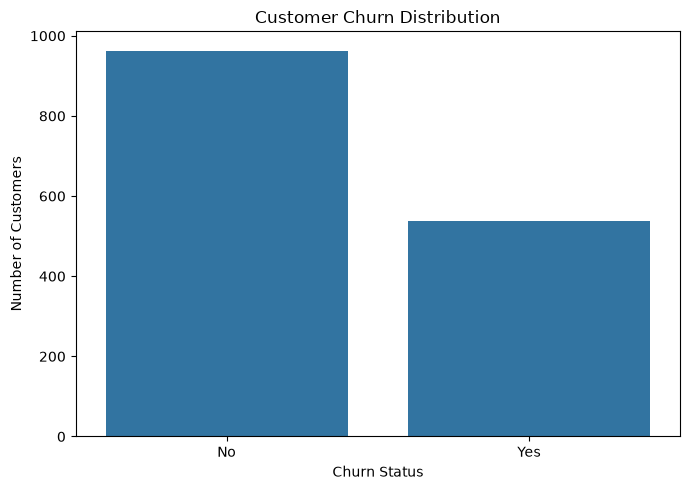

In [9]:
# Overall churn and retention overview

churn_summary = df["Churn"].value_counts().reset_index()
churn_summary.columns = ["Churn_Status", "Customers"]

print(churn_summary)

plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.savefig("../visualizations/churn_distribution.png", dpi=300)
plt.show()

       Plan  Churn_Rate
0     Basic   43.283582
1   Premium   33.676976
2  Standard   30.757801


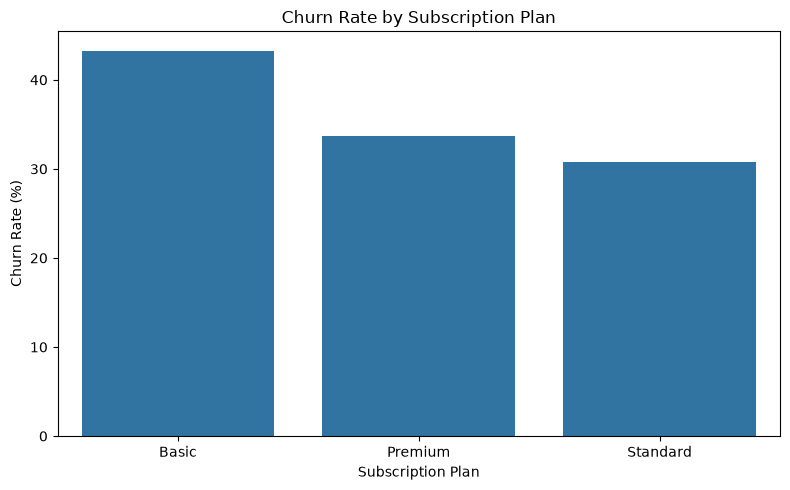

In [10]:
# Churn rate by subscription plan

plan_churn = (
    df.groupby("Plan")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="Churn_Rate")
)

print(plan_churn)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=plan_churn,
    x="Plan",
    y="Churn_Rate"
)

plt.title("Churn Rate by Subscription Plan")
plt.xlabel("Subscription Plan")
plt.ylabel("Churn Rate (%)")

plt.tight_layout()
plt.savefig("../visualizations/churn_by_plan.png", dpi=300)
plt.show()

    Region  Churn_Rate
0  Central   34.640523
1     East   35.164835
2    North   31.058020
3    South   37.873754
4     West   39.755352


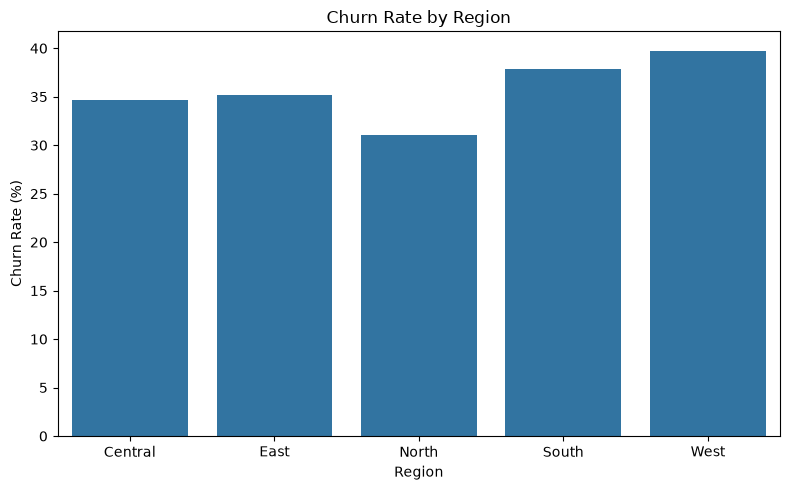

In [11]:
# Churn rate by region

region_churn = (
    df.groupby("Region")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="Churn_Rate")
)

print(region_churn)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=region_churn,
    x="Region",
    y="Churn_Rate"
)

plt.title("Churn Rate by Region")
plt.xlabel("Region")
plt.ylabel("Churn Rate (%)")

plt.tight_layout()
plt.savefig("../visualizations/churn_by_region.png", dpi=300)
plt.show()

   Tenure_Group  Churn_Rate
0    0-6 Months   44.295302
1   7-12 Months   36.774194
2  13-24 Months   35.168196
3  25-36 Months   35.313531
4  37-60 Months   33.922261


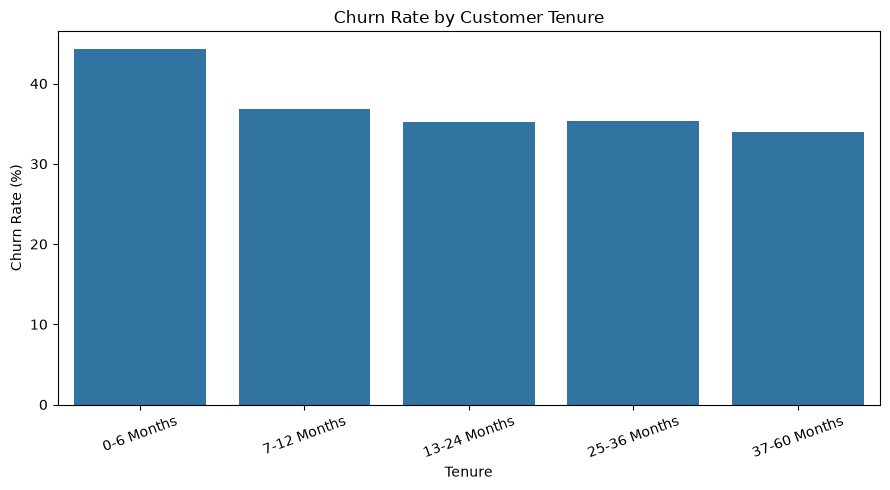

In [12]:
# Create tenure groups

df["Tenure_Group"] = pd.cut(
    df["Tenure_Months"],
    bins=[0, 6, 12, 24, 36, 60],
    labels=[
        "0-6 Months",
        "7-12 Months",
        "13-24 Months",
        "25-36 Months",
        "37-60 Months"
    ]
)

tenure_churn = (
    df.groupby("Tenure_Group", observed=False)["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="Churn_Rate")
)

print(tenure_churn)

plt.figure(figsize=(9, 5))
sns.barplot(
    data=tenure_churn,
    x="Tenure_Group",
    y="Churn_Rate"
)

plt.title("Churn Rate by Customer Tenure")
plt.xlabel("Tenure")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=20)

plt.tight_layout()
plt.savefig("../visualizations/churn_by_tenure.png", dpi=300)
plt.show()

  Churn  Satisfaction_Score
0    No            7.016511
1   Yes            6.781378


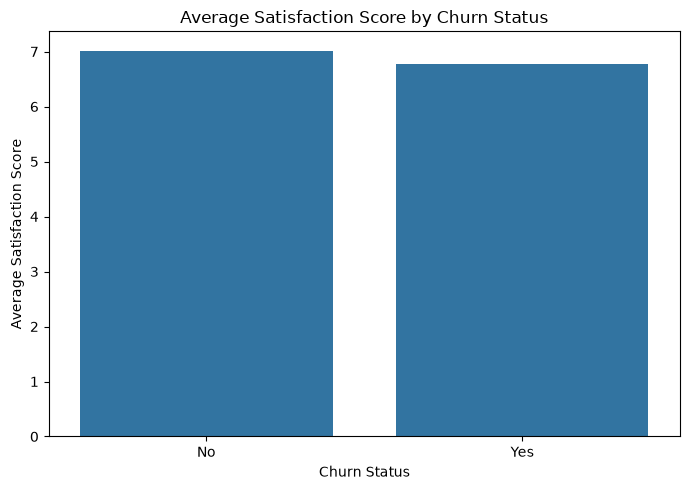

In [13]:
# Average satisfaction by churn status

satisfaction_churn = (
    df.groupby("Churn")["Satisfaction_Score"]
    .mean()
    .reset_index()
)

print(satisfaction_churn)

plt.figure(figsize=(7, 5))
sns.barplot(
    data=satisfaction_churn,
    x="Churn",
    y="Satisfaction_Score"
)

plt.title("Average Satisfaction Score by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Average Satisfaction Score")

plt.tight_layout()
plt.savefig("../visualizations/satisfaction_vs_churn.png", dpi=300)
plt.show()

  Churn  Support_Calls
0    No       1.943925
1   Yes       2.176909


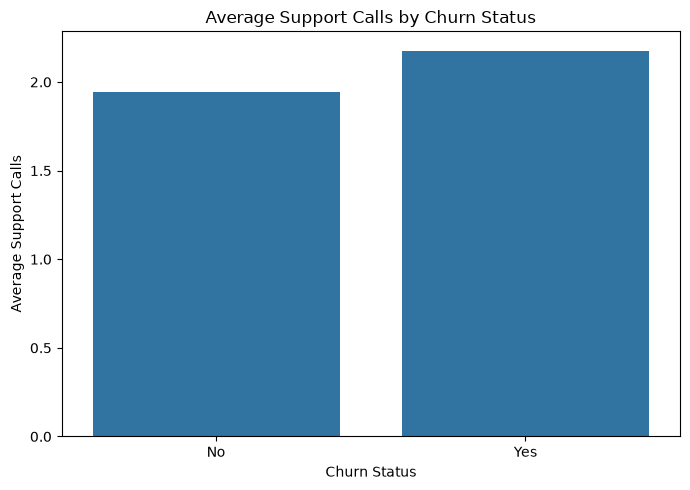

In [14]:
# Average support calls by churn status

support_churn = (
    df.groupby("Churn")["Support_Calls"]
    .mean()
    .reset_index()
)

print(support_churn)

plt.figure(figsize=(7, 5))
sns.barplot(
    data=support_churn,
    x="Churn",
    y="Support_Calls"
)

plt.title("Average Support Calls by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Average Support Calls")

plt.tight_layout()
plt.savefig("../visualizations/support_calls_vs_churn.png", dpi=300)
plt.show()

Average Lifetime Value by Churn Status:
Churn
No     1686.525514
Yes    1490.303184
Name: Lifetime_Value, dtype: float64


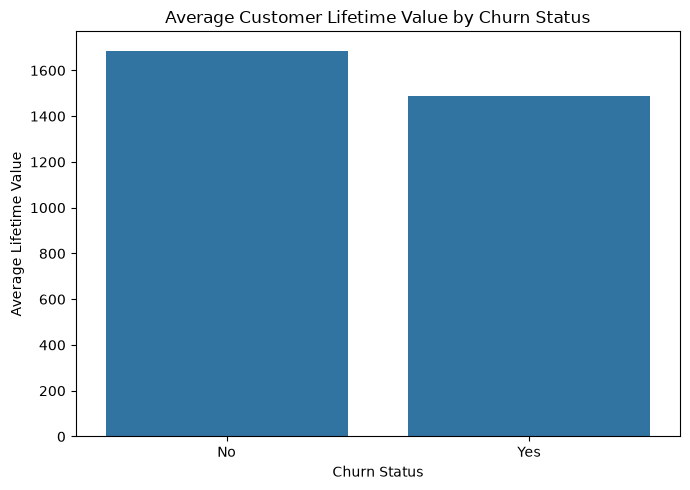

In [15]:
# Step 20: Lifetime Value vs Churn

ltv_by_churn = df.groupby("Churn")["Lifetime_Value"].mean()

print("Average Lifetime Value by Churn Status:")
print(ltv_by_churn)

plt.figure(figsize=(7, 5))
sns.barplot(
    x=ltv_by_churn.index,
    y=ltv_by_churn.values
)

plt.title("Average Customer Lifetime Value by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Average Lifetime Value")

plt.tight_layout()
plt.savefig("../visualizations/lifetime_value_vs_churn.png", dpi=300)
plt.show()

Average Lifetime Value by Tenure Group:
Tenure_Group
0-6 Months       186.491141
7-12 Months      496.360000
13-24 Months     937.556514
25-36 Months    1700.623729
37-60 Months    2646.332032
Name: Lifetime_Value, dtype: float64


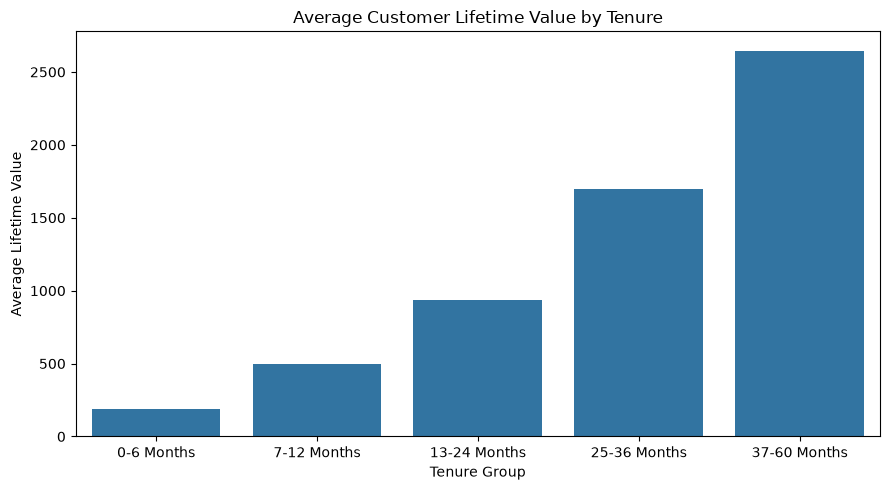

In [16]:
# Step 21: Customer Lifetime Trends

ltv_by_tenure = df.groupby("Tenure_Group")["Lifetime_Value"].mean()

print("Average Lifetime Value by Tenure Group:")
print(ltv_by_tenure)

plt.figure(figsize=(9, 5))
sns.barplot(
    x=ltv_by_tenure.index,
    y=ltv_by_tenure.values
)

plt.title("Average Customer Lifetime Value by Tenure")
plt.xlabel("Tenure Group")
plt.ylabel("Average Lifetime Value")

plt.tight_layout()
plt.savefig("../visualizations/lifetime_value_by_tenure.png", dpi=300)
plt.show()

In [17]:
# Step 22: Customer Risk Segmentation

def risk_level(row):
    score = 0

    if row["Contract_Type"] == "Monthly":
        score += 2

    if row["Satisfaction_Score"] <= 2:
        score += 2

    if row["Support_Calls"] >= 4:
        score += 2

    if row["Tenure_Months"] <= 12:
        score += 2

    if row["Plan"] == "Basic":
        score += 1

    if score >= 6:
        return "High Risk"
    elif score >= 3:
        return "Medium Risk"
    else:
        return "Low Risk"


df["Risk_Level"] = df.apply(risk_level, axis=1)

risk_summary = df["Risk_Level"].value_counts()

print("Customer Risk Segmentation:")
print(risk_summary)

Customer Risk Segmentation:
Risk_Level
Low Risk       987
Medium Risk    486
High Risk       27
Name: count, dtype: int64


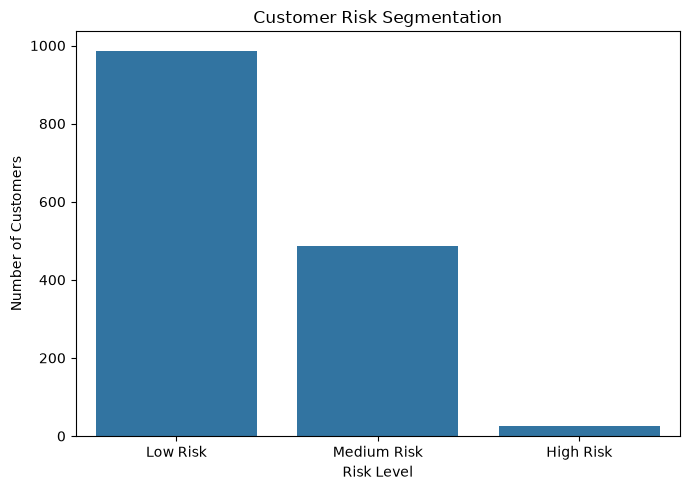

In [18]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=risk_summary.index,
    y=risk_summary.values
)

plt.title("Customer Risk Segmentation")
plt.xlabel("Risk Level")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.savefig("../visualizations/customer_risk_segmentation.png", dpi=300)
plt.show()

In [19]:
# Step 23: Final KPI Summary

kpi_summary = pd.DataFrame({
    "KPI": [
        "Total Customers",
        "Churned Customers",
        "Retained Customers",
        "Churn Rate (%)",
        "Retention Rate (%)",
        "Average Tenure (Months)",
        "Average Monthly Charge",
        "Average Lifetime Value",
        "Average Satisfaction Score"
    ],
    "Value": [
        total_customers,
        churned_customers,
        retained_customers,
        round(churn_rate, 2),
        round(retention_rate, 2),
        round(average_tenure, 2),
        round(average_monthly_charge, 2),
        round(average_lifetime_value, 2),
        round(average_satisfaction, 2)
    ]
})

kpi_summary

,KPI,Value
0,Total Customers,1500.00
1,Churned Customers,537.00
2,Retained Customers,963.00
3,Churn Rate (%),35.80
4,Retention Rate (%),64.20
5,Average Tenure (Months),29.80
6,Average Monthly Charge,53.95
7,Average Lifetime Value,1616.28
8,Average Satisfaction Score,6.93


In [20]:
# Step 24: Highest Churn Contract Type

contract_churn = (
    df.groupby("Contract_Type")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

print("Churn Rate by Contract Type:")
print(contract_churn)

highest_contract = contract_churn.index[0]
highest_contract_rate = contract_churn.iloc[0]

print(
    f"\nHighest churn contract type: {highest_contract} "
    f"({highest_contract_rate:.2f}%)"
)

Churn Rate by Contract Type:
Contract_Type
Monthly     43.684211
Two Year    27.868852
One Year    27.586207
Name: Churn, dtype: float64

Highest churn contract type: Monthly (43.68%)


In [21]:
# Step 25: Highest Churn Plan

plan_churn = (
    df.groupby("Plan")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

print("Churn Rate by Plan:")
print(plan_churn)

highest_plan = plan_churn.index[0]
highest_plan_rate = plan_churn.iloc[0]

print(
    f"\nHighest churn plan: {highest_plan} "
    f"({highest_plan_rate:.2f}%)"
)

Churn Rate by Plan:
Plan
Basic       43.283582
Premium     33.676976
Standard    30.757801
Name: Churn, dtype: float64

Highest churn plan: Basic (43.28%)


In [23]:
# Recreate churn_reasons

churned_df = df[df["Churn"] == "Yes"]

churn_reasons = churned_df["Churn_Reason"].value_counts()

print(churn_reasons)

Churn_Reason
Customer Support    125
Competitor Offer    112
Lack of Features    108
High Price          106
Poor Service         86
Name: count, dtype: int64


In [24]:
# Step 26: Most Common Churn Reason

top_churn_reason = churn_reasons.index[0]
top_churn_reason_count = churn_reasons.iloc[0]

print("Most Common Churn Reason:", top_churn_reason)
print("Customers:", top_churn_reason_count)

Most Common Churn Reason: Customer Support
Customers: 125


In [25]:
# Step 27: Satisfaction Comparison

satisfaction_by_churn = df.groupby("Churn")["Satisfaction_Score"].mean()

print("Average Satisfaction Score:")
print(satisfaction_by_churn)

churned_satisfaction = satisfaction_by_churn["Yes"]
retained_satisfaction = satisfaction_by_churn["No"]

print(f"\nChurned Customers: {churned_satisfaction:.2f}")
print(f"Retained Customers: {retained_satisfaction:.2f}")
print(
    f"Difference: "
    f"{retained_satisfaction - churned_satisfaction:.2f}"
)

Average Satisfaction Score:
Churn
No     7.016511
Yes    6.781378
Name: Satisfaction_Score, dtype: float64

Churned Customers: 6.78
Retained Customers: 7.02
Difference: 0.24


In [26]:
# Step 28: Support Call Comparison

support_by_churn = df.groupby("Churn")["Support_Calls"].mean()

print("Average Support Calls:")
print(support_by_churn)

churned_support = support_by_churn["Yes"]
retained_support = support_by_churn["No"]

print(f"\nChurned Customers: {churned_support:.2f}")
print(f"Retained Customers: {retained_support:.2f}")
print(
    f"Difference: "
    f"{churned_support - retained_support:.2f}"
)

Average Support Calls:
Churn
No     1.943925
Yes    2.176909
Name: Support_Calls, dtype: float64

Churned Customers: 2.18
Retained Customers: 1.94
Difference: 0.23


In [27]:
# Step 29: Analysis Summary Tables

contract_summary = (
    df.groupby("Contract_Type")
    .agg(
        Customers=("Customer_ID", "count"),
        Churned=("Churn", lambda x: (x == "Yes").sum()),
        Churn_Rate=("Churn", lambda x: (x == "Yes").mean() * 100)
    )
    .reset_index()
)

plan_summary = (
    df.groupby("Plan")
    .agg(
        Customers=("Customer_ID", "count"),
        Churned=("Churn", lambda x: (x == "Yes").sum()),
        Churn_Rate=("Churn", lambda x: (x == "Yes").mean() * 100)
    )
    .reset_index()
)

region_summary = (
    df.groupby("Region")
    .agg(
        Customers=("Customer_ID", "count"),
        Churned=("Churn", lambda x: (x == "Yes").sum()),
        Churn_Rate=("Churn", lambda x: (x == "Yes").mean() * 100)
    )
    .reset_index()
)

print("Contract Summary")
display(contract_summary)

print("Plan Summary")
display(plan_summary)

print("Region Summary")
display(region_summary)

Contract Summary


,Contract_Type,Customers,Churned,Churn_Rate
0,Monthly,760,332,43.684211
1,One Year,435,120,27.586207
2,Two Year,305,85,27.868852


Plan Summary


,Plan,Customers,Churned,Churn_Rate
0,Basic,536,232,43.283582
1,Premium,291,98,33.676976
2,Standard,673,207,30.757801


Region Summary


,Region,Customers,Churned,Churn_Rate
0,Central,306,106,34.640523
1,East,273,96,35.164835
2,North,293,91,31.058020
3,South,301,114,37.873754
4,West,327,130,39.755352


In [28]:
# Step 30: Final Business Insights

print("========== CUSTOMER CHURN INSIGHTS ==========\n")

print(f"1. Overall Churn Rate: {churn_rate:.2f}%")
print(f"   Retention Rate: {retention_rate:.2f}%\n")

print(
    f"2. Highest Churn Contract Type: "
    f"{highest_contract} ({highest_contract_rate:.2f}%)"
)

print(
    f"3. Highest Churn Plan: "
    f"{highest_plan} ({highest_plan_rate:.2f}%)"
)

print(
    f"4. Most Common Churn Reason: "
    f"{top_churn_reason} ({top_churn_reason_count} customers)"
)

print(
    f"5. Average Satisfaction - Churned Customers: "
    f"{churned_satisfaction:.2f}"
)

print(
    f"6. Average Satisfaction - Retained Customers: "
    f"{retained_satisfaction:.2f}"
)

print(
    f"7. Average Support Calls - Churned Customers: "
    f"{churned_support:.2f}"
)

print(
    f"8. Average Support Calls - Retained Customers: "
    f"{retained_support:.2f}"
)

print(
    f"9. Average Customer Lifetime Value: "
    f"{average_lifetime_value:.2f}"
)

print(
    f"10. Average Customer Tenure: "
    f"{average_tenure:.2f} months"
)

print("\n========== RECOMMENDED ACTIONS ==========\n")

print("• Focus retention efforts on high-risk customers.")
print("• Improve customer satisfaction and service quality.")
print("• Monitor customers with frequent support calls.")
print("• Design targeted offers for customers on high-churn plans.")
print("• Encourage longer-term contracts to improve retention.")
print("• Address the most common reasons for customer churn.")

========== CUSTOMER CHURN INSIGHTS ==========

1. Overall Churn Rate: 35.80%
   Retention Rate: 64.20%

2. Highest Churn Contract Type: Monthly (43.68%)
3. Highest Churn Plan: Basic (43.28%)
4. Most Common Churn Reason: Customer Support (125 customers)
5. Average Satisfaction - Churned Customers: 6.78
6. Average Satisfaction - Retained Customers: 7.02
7. Average Support Calls - Churned Customers: 2.18
8. Average Support Calls - Retained Customers: 1.94
9. Average Customer Lifetime Value: 1616.28
10. Average Customer Tenure: 29.80 months

========== RECOMMENDED ACTIONS ==========

• Focus retention efforts on high-risk customers.
• Improve customer satisfaction and service quality.
• Monitor customers with frequent support calls.
• Design targeted offers for customers on high-churn plans.
• Encourage longer-term contracts to improve retention.
• Address the most common reasons for customer churn.


In [29]:
# Step 31: Risk Level Analysis

risk_analysis = (
    df.groupby("Risk_Level")
    .agg(
        Customers=("Customer_ID", "count"),
        Churned=("Churn", lambda x: (x == "Yes").sum()),
        Churn_Rate=("Churn", lambda x: (x == "Yes").mean() * 100),
        Avg_Lifetime_Value=("Lifetime_Value", "mean"),
        Avg_Satisfaction=("Satisfaction_Score", "mean")
    )
    .reset_index()
)

risk_analysis["Churn_Rate"] = risk_analysis["Churn_Rate"].round(2)
risk_analysis["Avg_Lifetime_Value"] = risk_analysis["Avg_Lifetime_Value"].round(2)
risk_analysis["Avg_Satisfaction"] = risk_analysis["Avg_Satisfaction"].round(2)

risk_analysis

,Risk_Level,Customers,Churned,Churn_Rate,Avg_Lifetime_Value,Avg_Satisfaction
0,High Risk,27,17,62.96,261.94,6.87
1,Low Risk,987,289,29.28,1992.71,6.93
2,Medium Risk,486,231,47.53,927.03,6.95


In [30]:
# Step 32: Save Cleaned Dataset

df.to_csv(
    "../data/cleaned_customer_churn_data.csv",
    index=False
)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [32]:
# Recreate Churn Reason Summary

churned_df = df[df["Churn"] == "Yes"]

churn_reasons = churned_df["Churn_Reason"].value_counts()

churn_reason_percentage = (
    churn_reasons / churn_reasons.sum() * 100
).round(2)

churn_reason_summary = pd.DataFrame({
    "Churned_Customers": churn_reasons,
    "Percentage": churn_reason_percentage
})

print(churn_reason_summary)

                  Churned_Customers  Percentage
Churn_Reason                                   
Customer Support                125       23.28
Competitor Offer                112       20.86
Lack of Features                108       20.11
High Price                      106       19.74
Poor Service                     86       16.01


In [33]:
# Step 33: Export Analysis Results to Excel

with pd.ExcelWriter(
    "../report/customer_churn_analysis.xlsx",
    engine="openpyxl"
) as writer:

    kpi_summary.to_excel(
        writer,
        sheet_name="KPIs",
        index=False
    )

    contract_summary.to_excel(
        writer,
        sheet_name="Contract Analysis",
        index=False
    )

    plan_summary.to_excel(
        writer,
        sheet_name="Plan Analysis",
        index=False
    )

    region_summary.to_excel(
        writer,
        sheet_name="Region Analysis",
        index=False
    )

    churn_reason_summary.to_excel(
        writer,
        sheet_name="Churn Reasons"
    )

    risk_analysis.to_excel(
        writer,
        sheet_name="Risk Analysis",
        index=False
    )

    ltv_by_tenure.to_frame(
        name="Average_Lifetime_Value"
    ).to_excel(
        writer,
        sheet_name="Lifetime Trends"
    )

print("Excel report created successfully.")

Excel report created successfully.
